In [ ]:
%%html
<center><marquee style='width: 60%; color: blue;'><b>✌ ¡Hola a todos! Hoy es una clase importante ✌ </b></marquee><center>

<table>
        <td>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="400"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue"> Conceptos Machine Learning </p> Clasificación </p> KNN- vecinos más cercanos </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Machine Learning </p></tp>
            <tp><p style="font-size:115%;text-align:center">Diplomado 2026-2</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>




# <FONT SIZE=5 COLOR="purple"> 1. Ejemplo Práctico </FONT>

- En esta sección haremos un ejemplo práctico.

- Iniciaremos indicando las librerías que debemos usar.

## <FONT SIZE=4 COLOR="blue"> 1.1 Librerías de trabajo </FONT>

In [ ]:
# Manipulación de data.frames
import pandas       as pd
import numpy        as np

# Librerías para Gráficos
import matplotlib.pyplot  as plt
import seaborn            as sns
import plotly.express     as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento/escalar los datos
from sklearn.preprocessing      import StandardScaler, MinMaxScaler

# Para aplicar k-nearest neighbors

# modelos de clasificación
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier

# Métricas de evaluación
from sklearn                    import metrics
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score
from imblearn.metrics           import specificity_score

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV

# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

## <FONT SIZE=4 COLOR="blue"> 1.2 Contexto del problema </FONT>

En este caso, veremos un caso típico de problema de clasificación. Queremos predecir si una integrante de una muestra que representa a una población, tiene diabetes. Queremos hacer esto a partir de múltiples variables que tenemos de cada una de las pacientes:

- ***Pregnancies***: Número de embarazos que ha tenido en su vida
- ***Glucose***: Nivel de concentración de glucosa en sangre
- ***BloodPressure***: Presión arterial
- ***SkinThikness***: Espesor de piel a la altura del triceps
- ***Insulin***: Respuesta a dosis de insulina en 2 horas
- ***BMI***: Índice de masa corporal
- ***DiabetesPedigreeFunction***: Presencia de diabetes en ascendencia directa
- ***Age***: Edad del paciente
- ***Outcome***: Variable que queremos predecir:
   - $1$ : Tiene diabetes
   - $0$ : No tiene diabetes



## <FONT SIZE=4 COLOR="blue"> 1.3 Importar los datos </FONT>

Lo primero que haremos es importar los datos que están en el siguiente link o pueden ser descargados de la página de Kaggle.

https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/pima_diabetes_2000.csv

In [ ]:
diabetes= pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/pima_diabetes_2000.csv")

## <FONT SIZE=4 COLOR="blue"> 1.4 Exploración rápida de los datos </FONT>

Antes de hacer cualquier modelo de machine learning o análisis similar es fundamental entender y explorar las variables del conjunto de datos.

In [ ]:
# cabeza de los datos (primeros)
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,7,160,82,16,307,28.79,0.29,40,1
1,9,135,75,28,107,36.00,0.55,45,1
2,1,102,38,10,36,29.16,0.88,30,0
3,4,139,75,28,227,34.81,0.93,34,1
4,7,133,80,38,285,44.68,0.36,47,1


In [ ]:
# revisar la información de los datos
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [ ]:
# estadísticos descriptivos
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.917000,119.578000,68.950500,23.027000,96.374000,32.069805,0.469155,33.424000,0.349000
std,2.617544,28.304337,15.105202,10.439864,92.696502,5.986272,0.245845,9.450179,0.476773
min,0.000000,41.000000,0.000000,5.000000,2.000000,12.200000,0.080000,21.000000,0.000000
25%,2.000000,99.000000,64.000000,15.000000,31.000000,27.947500,0.290000,26.000000,0.000000
50%,4.000000,115.000000,71.000000,23.000000,74.500000,31.815000,0.420000,31.000000,0.000000
75%,6.000000,138.000000,77.000000,31.000000,131.000000,35.862500,0.590000,40.000000,1.000000
max,14.000000,199.000000,106.000000,66.000000,690.000000,62.240000,2.190000,73.000000,1.000000


In [ ]:
# contar las categorias de la variable resultado
diabetes["Outcome"].value_counts()

,count
Outcome,
0,1302
1,698


**Cuidado 🍳**: En esta parte hay que tener especial atención,  particularmente en otros algoritmos. Cuando los datos están desbalanceados pueden afectar los resultados. Para esto se puede usar algunas técnicas de balanceo de datos: *subsampling*, *oversampling* y *smote*.

- Para continuar con el ejercicio, trabajaremos con las clases como están.

In [47]:
def evaluacion_modelo(modelo, X_train, y_train, X_test, y_test, nombre_modelo = "modelo",graficar = True):
  # definir las predicciones en conjuntos de train y test
  y_pred_train = modelo.predict(X_train)
  y_pred_test  = modelo.predict(X_test)
  # matrices de confusión
  if graficar :
    # Calcular matrices de confusión
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test = confusion_matrix(y_test, y_pred_test)
    # ejes para gráficas
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # matriz de confusión en train
    sns.heatmap(pd.DataFrame(cm_train),                # data.frame
                  annot=True,                          # colocar números de las cajitas
                  annot_kws = {'size':20},             # tamaño de la letra
                  cmap="YlOrRd",                       # color de la letra 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu'
                  fmt='g',                             # para que salgan los número no : notación científica
                  ax=axes[0])
    axes[0].set_title(f'Matriz de Confusión - Train-{nombre_modelo}', fontsize=14)
    axes[0].set_xlabel('Predicciones')
    axes[0].set_ylabel('Valores Reales')
    # matriz de confusión en test
    sns.heatmap(pd.DataFrame(cm_test),
              annot=True,
              fmt='g',
              cmap='YlOrRd',
              annot_kws={'size':20},
              ax=axes[1])
    axes[1].set_title(f'Matriz de Confusión - Test-{nombre_modelo}', fontsize=14)
    axes[1].set_xlabel('Predicciones')
    axes[1].set_ylabel('Valores Reales')
    plt.tight_layout()
    plt.show()
  # metricas en train
  metrics=["accuracy", "recall" , "specificity", "precision", "f1"]
  # valores
  values_train = [accuracy_score(y_train,y_pred_train),
          recall_score(y_train,y_pred_train),
          specificity_score(y_train,y_pred_train),
          precision_score(y_train,y_pred_train),
          f1_score(y_train,y_pred_train)]
  values_test = [accuracy_score(y_test,y_pred_test),
          recall_score(y_test,y_pred_test),
          specificity_score(y_test,y_pred_test),
          precision_score(y_test,y_pred_test),
          f1_score(y_test,y_pred_test)]

  df = pd.DataFrame({f"{nombre_modelo}_train" : values_train,
                      f"{nombre_modelo}_test" : values_test}, index = metrics)
  return df


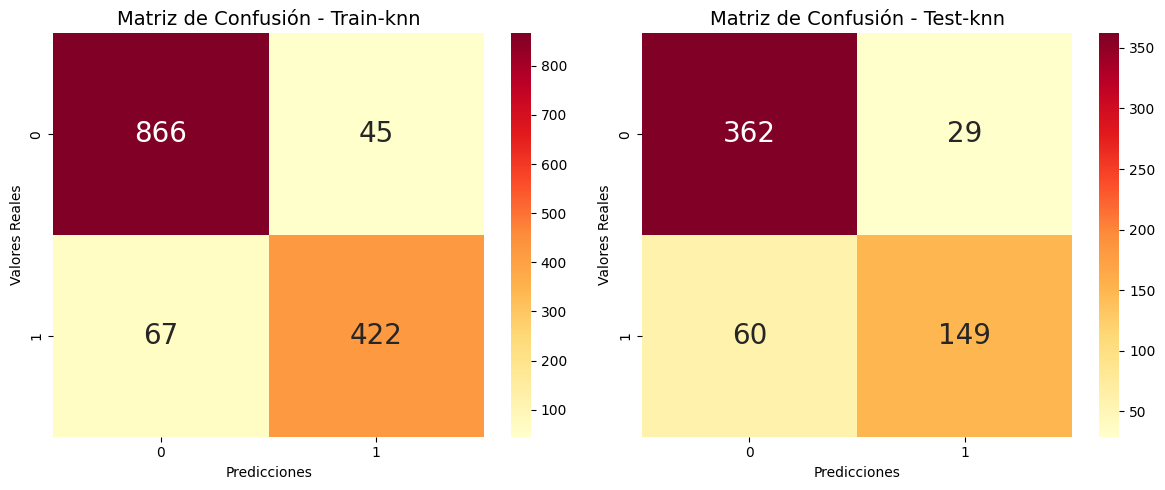

,knn_train,knn_test
accuracy,0.920000,0.851667
recall,0.862986,0.712919
specificity,0.950604,0.925831
precision,0.903640,0.837079
f1,0.882845,0.770026


In [53]:
# 1. Seleccionar variable objetivo y predictoras
# la variable objetivo
y = diabetes["Outcome"] # diabetes.resultados
# las variables predictoras
X = diabetes.drop("Outcome", axis=1)

# 2. Dividir en dos conjuntos: entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify = y,             # garantiza que los resultados se distribuyan igual
                                                    random_state = 123,        # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.3)          # tamaño del conjunto de prueba (también se puede train)


# 3. escalar las variables.
# definimos la función para escalar
escalar = StandardScaler()
# lo aplicamos a los conjuntos (s: scaler)
X_train_s = escalar.fit_transform(X_train)
X_test_s = escalar.transform(X_test)

# 4. Generar el modelo
# definir el modelo
# defecto toma 5 vecinos
modelo_knn = KNeighborsClassifier()
# entrenar el modelo
modelo_knn.fit(X_train_s,y_train)

# 5. Evaluar el modelo
evaluacion_modelo(modelo_knn, X_train_s, y_train, X_test_s, y_test, nombre_modelo = "knn",graficar = True)


| Métrica   | ¿Por qué es importante en detección de diabetes? |
|---------- |---------|
| Recall       | Es clave porque queremos detectar todos los pacientes con diabetes y minimizar los falsos negativos (FN). <br> Un FN significaría que un paciente enfermo no recibe tratamiento a tiempo.  |
| F1-Score    | Si hay un desbalance en los datos (pocos casos positivos), ayuda a equilibrar precisión y recall.<br> Evita que un modelo con alta precisión pero bajo recall o viceversa sea engañoso.   |
| Precision    | Es importante, pero no tan prioritaria como el recall. <br>Un alto recall puede generar algunos falsos positivos (FP), pero es preferible hacer más pruebas a pacientes <br> falsamente etiquetados con diabetes que dejar enfermos sin diagnóstico.   |
| Especificidad    | Puede ser útil, pero no es la métrica principal. <br>Si la especificidad es demasiado alta, podría significar que el modelo no detecta suficientes casos de diabetes.   |

Otra forma de revisar las métricas es con el *classification_report*

In [38]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90       391
           1       0.86      0.73      0.79       209

    accuracy                           0.86       600
   macro avg       0.86      0.83      0.85       600
weighted avg       0.86      0.86      0.86       600



## <FONT SIZE=5 COLOR="Purple"> 1.5 Predicción en KNN </FONT>



En este conjunto de datos tenemos algunos datos para hacer predicciones

In [ ]:
diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,7,160,82,16,307,28.79,0.29,40,1
1,9,135,75,28,107,36.00,0.55,45,1
2,1,102,38,10,36,29.16,0.88,30,0
3,4,139,75,28,227,34.81,0.93,34,1
4,7,133,80,38,285,44.68,0.36,47,1
...,...,...,...,...,...,...,...,...,...
1995,4,88,61,13,46,22.98,0.27,26,0
1996,2,142,79,20,99,43.21,0.28,28,1
1997,7,124,74,12,200,39.38,0.27,42,1
1998,5,117,80,33,88,34.05,1.13,31,1


In [ ]:
diabetes_predicciones = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/pima_diabetes_100_para_predecir.csv")
diabetes_predicciones.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,167,90,17,266,33.01,0.202,55
1,3,95,60,24,60,30.57,0.655,28
2,5,90,70,34,61,35.34,0.400,24
3,7,140,74,7,40,26.58,0.319,48
4,4,94,64,23,20,27.79,0.421,33


In [ ]:
probabilidades = modelo_knn.predict_proba(diabetes_predicciones)[:,1]

In [ ]:
predicciones = modelo_knn.predict(diabetes_predicciones)

In [ ]:
# predicciones y las probabilidades
diabetes_predicciones["predicciones"] = predicciones
diabetes_predicciones["probab"] = probabilidades
diabetes_predicciones.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,predicciones,probab
0,6,167,90,17,266,33.01,0.202,55,1,0.875
1,3,95,60,24,60,30.57,0.655,28,1,1.000
2,5,90,70,34,61,35.34,0.400,24,1,1.000
3,7,140,74,7,40,26.58,0.319,48,1,1.000
4,4,94,64,23,20,27.79,0.421,33,1,1.000


# <FONT SIZE=5 COLOR="purple"> 7. Validación Cruzada </FONT>

La **validación cruzada**, o *cross validation*, es una técnica utilizada para evaluar los resultados obtenidos de un modelo de *machine learning* y garantizar que son independientes de los conjuntos de entrenamiento ($X_{train}$) y prueba ($X_{test}$).

- Cuando usamos la función de *sklearn*:

$$train\_test\_split(X, y, random\_state = 123 )$$

se extraen dos muestras aleatorias como conjuntos de entrenamiento y prueba. Luego se hace el proceso de entrenamiento y validación del modelo, teniendo como referencias las muestras seleccionadas. Sin embargo, una pregunta natural es:

**¿Qué sucede si tomo otras muestras como conjunto de entrenamiento y de prueba, obtendré los mismos resultados?**

Para responder lo anterior, debemos seleccionar varias muestras que correspondan a conjunto de entrenamiento y prueba diferentes y hacer el análisis del modelo. Precisamente, esto es lo que hace el proceso de validación cruzada.

Se divide el conjunto de datos en $n$ partes, de las cuales se toma una como conjunto de *prueba* y las otras $n-1$ como conjunto de entrenamiento. Y vamos rotando el conjunto de prueba, tal y como se muestra en la siguiente figura.

<br>

<center><img src="https://github.com/Fabian830348/cursos/blob/master/val_cruzada/validation1.png?raw=true?" alt="centered image" width="600" height="350"></center>

<br>

In [54]:
# Validación cruzada k fold
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline        import make_pipeline

modelo_knn = KNeighborsClassifier()

pipeline = make_pipeline(StandardScaler(),
                         modelo_knn)

#kfold_validacion = KFold(10)                              # divide los datos en 10 pliegues.
resultados = cross_val_score(pipeline,                     # modelo aplicado
                             X,                            # conjunto de predictores
                             y,                            # variable de respuesta
                             cv = 10,                      # número de divisiones en cross-validation.
                             scoring = "accuracy")         # se puede escoger la métrica.
print(resultados)                                          # para ver la variable resultados.
resultados.mean()

[0.905 0.875 0.895 0.865 0.88  0.9   0.9   0.845 0.88  0.83 ]


np.float64(0.8775000000000001)

Obtenemos en promedio 0.87 de *Accuracy*

# <FONT SIZE=5 COLOR="purple"> 8. Parámetro vs Hiperparámetro </FONT>

Iniciaremos definiendo los siguientes conceptos:

**Parámetros**:

- Son variables propias del modelo y que se obtienen de forma automática usando el conjunto de entrenamiento. Es decir, se estiman a partir de los datos.  

- Por ejemplo, en regresión lineal buscamos una ecuación de la forma $y= \beta_1 x +\beta_0$ y precisamente este tipo de modelo nos ayuda a encontrar estos valores de $\beta_1$ y $\beta_0$.

***Hiperparámetros:***

- Son parámetros de aprendizaje automático que se eligen antes de iniciar el proceso de aprendizaje automático.

- Son variables externas al modelo que no se obtienen automáticamente a partir de los datos.

- Son ajustables y pueden afectar directamente a la forma en la que se entrena un modelo de aprendizaje automático.

Algunos de estos hiperparámetros son:

- *Número de vecinos en knn*

- *Número de épocas en redes neuronales*

- *Número de ramas en un árbol de decisión*

- *Número de clústeres en un algoritmo de agrupamiento*

- *Tipo de kernel en SVM*

Los hiperparámetros son flexibles, ya que se refieren a cualquier elemento en el machine learning y el deep learning que decida sus valores o elija su configuración antes de que comience el entrenamiento y cuyos valores permanecen iguales cuando se finaliza el entrenamiento.

Los parámetros, por su lado, son características inherentes al modelo. Esto quiere decir que se aprenden o se estiman a partir de los datos brindados durante el entrenamiento, ya que el algoritmo que se use intentará aprender a partir de las características de entrada y la variable objetivo.

**Hiperparámetros de KNN**

Particularmente en el algoritmo de ***knn***, k-vecinos más cercanos tenemos los siguientes hiperpámetros.

- El ***número de vecinos*** $k$.

- Las ***métricas***. Las más clásicas se pueden seleccionar entre:

   - Euclideana
   - Manhattan
   - Minkowski

- Los ***pesos*** en las métricas.

   - Uniformes
   - Respecto a la distancia.  

Podemos ver la documentación para ampliar la información

[ALGORITMO KNN-sklearn 🌎](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)


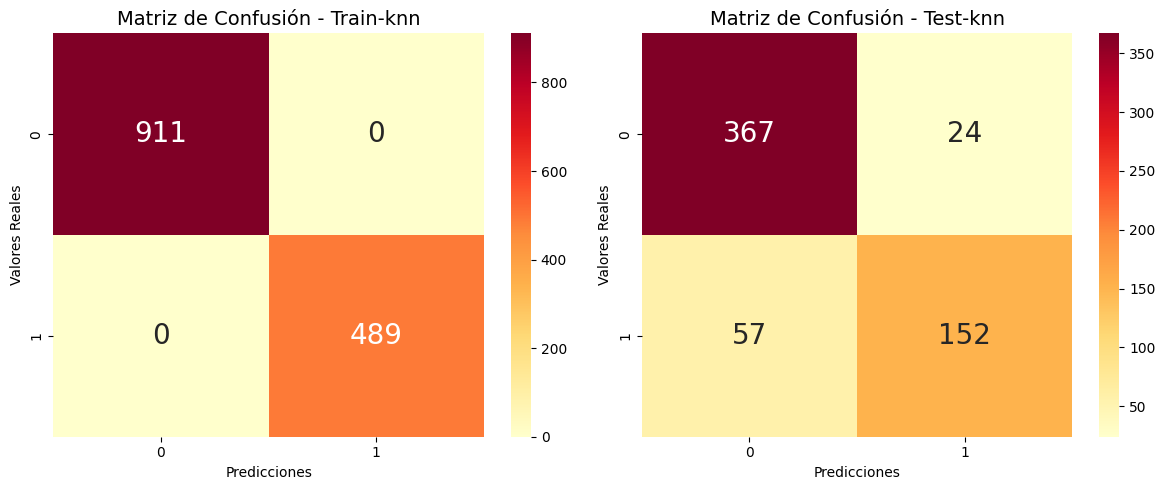

,knn_train,knn_test
accuracy,1.0,0.865000
recall,1.0,0.727273
specificity,1.0,0.938619
precision,1.0,0.863636
f1,1.0,0.789610


In [59]:
from sklearn import metrics
#metrics.confusion_matrix(y_test, y_pred)

# 1. Seleccionar variable objetivo y predictoras
# la variable objetivo
y = diabetes["Outcome"]
# las variables predictoras
X = diabetes.drop("Outcome", axis=1)

# 2. Dividir en dos conjuntos: entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify = y,             # garantiza que los resultados se distribuyan igual
                                                    random_state = 123,        # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.3)          # tamaño del conjunto de prueba (también se puede train)

# 3. Escalar las variables
escalar = StandardScaler()
X_train_s = escalar.fit_transform(X_train)
X_test_s = escalar.transform(X_test)

# 4. Mefinir el modelo (hiperparámetros)
modelo_knn_2 = KNeighborsClassifier(n_neighbors= 7,        # 4,5,6,, etc
                                    metric = "euclidean",  # minkowski, manhattan, euclidean
                                    weights = "distance")   # uniform , distance

# 5. Entrenar el modelo
modelo_knn_2.fit(X_train_s,y_train)

# 6. Evaluar el modelo
evaluacion_modelo(modelo_knn_2, X_train_s, y_train, X_test_s, y_test, nombre_modelo = "knn",graficar = True)

# <FONT SIZE=5 COLOR="purple"> 9. Búsqueda en Grilla </FONT>

- La ***búsqueda en grilla*** (grid search) es un método que busca las mejores combinaciones de hiperparámetros que hacen que un modelo tenga el error más bajo, es decir, estimaciones más precisas.

- En cada combinación de hiperparámetros, la búsqueda en grilla aplica el proceso de *cross-validation* con el fin de dar una mejor evaluación del modelo en cada punto.

- Cuando hablamos de búsqueda en grilla tenemos algunas alternativas: Grid Search y Random Grid Search. La primera se denomina propiamente *Grid Search* y en este método, se toman todas las combinaciones posibles de los hiperparámetros que se van a revisar. Como se ilustra en la siguiente gráfica.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/val_cruzada/grid1.png?raw=true?" alt="centered image" width="600" height="350"></center>
<br>

- Por otro lado, tenemos el ***Random Search***, que es una versión del primero donde no se toman todas las combinaciones de hiperparámetros sino que se selecciona una determinada cantidad aleatoria de combinaciones. Este método es útil cuando se tienen muchos hiperparámetros y el procesamiento puede demorarse.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/val_cruzada/grid2.png?raw=true?" alt="centered image" width="600" height="400"></center>

Para hacer la búsqueda en grilla, vamos a considerar los siguientes parámetros

1. El número de vecinos $k$ : [1,20]
2. Las métricas : *euclideana* y *manhattan*
3. Los pesos: "uniformes" o basados en "distancia"

De acuerdo con lo anterior tenemos

$$(20 \, vecinos) \times ( 2 \, metricas) \times ( 2 \, pesos) = 80$$

combinaciones de parámetros.

In [ ]:
from sklearn.pipeline import Pipeline

# Crear pipeline con escalador y modelo
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# definimos los parámetros que vamos a combinar. Diccionario
grid_params = {"knn__n_neighbors" : list(range(1, 21)),         # se recorre la lista en k
               "knn__weights" : ["uniform","distance"],         # se establecen los pesos
               "knn__metric" : ["euclidean","manhattan"]}       # se establecen las métricas

# hacemos la búsqueda en grilla con 5-folds
Grid_Search = GridSearchCV(pipe,                                     # el modelo aplicado
                           grid_params,                             # los parámetros que van a variar
                           cv = 10,                                 # el número de folds
                           verbose = 1)                             # para que imprima resultados. Posibilidades: 1,2 o 3
# Entrenar el modelo obtenido arriba
g_res = Grid_Search.fit(X_train,y_train)

Fitting 10 folds for each of 80 candidates, totalling 800 fits


Revisemos los siguientes elementos

In [ ]:
# el mejor accuracy
print("Mejor score: ",g_res.best_score_)
# los mejores hiperparámetros
print("Mejores hiperparámetros", g_res.best_params_)
# el mejor modelo
modelo_knn_best = g_res.best_estimator_

Mejor score:  0.8814285714285715
Mejores hiperparámetros {'knn__metric': 'manhattan', 'knn__n_neighbors': 8, 'knn__weights': 'distance'}
